Демонстрация движения шара:
1. Качение по наклонной плоскости без начальной скорости


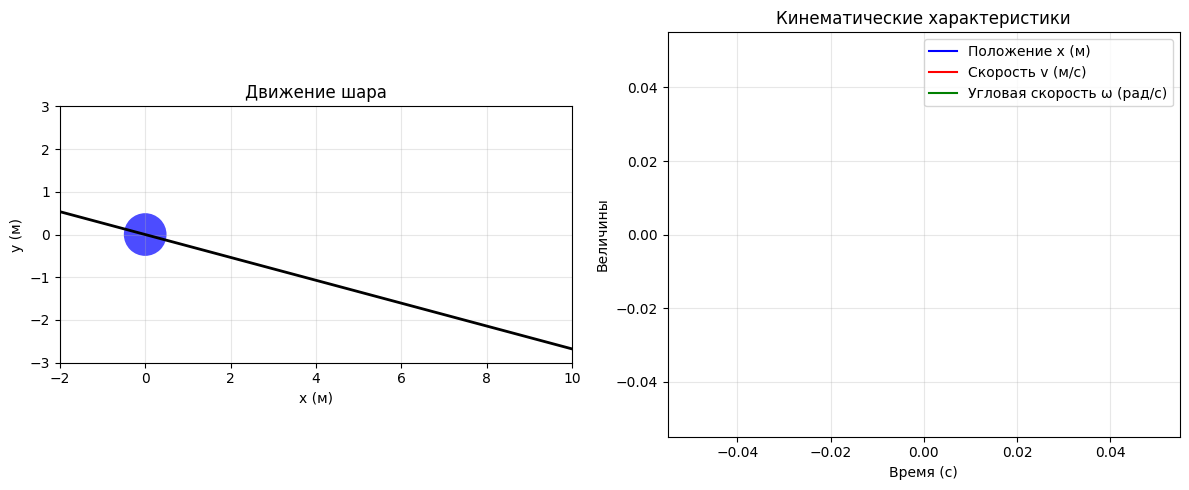

2. Качение по горизонтальной плоскости с начальной скоростью


<Figure size 640x480 with 0 Axes>

3. Проскальзывание (большой коэффициент трения)


<Figure size 640x480 with 0 Axes>

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle
import matplotlib.transforms as transforms

class RollingBall:
    def __init__(self, radius=0.5, mass=1.0, mu=0.3, g=9.81):
        # Параметры шара
        self.radius = radius
        self.mass = mass
        self.moment_of_inertia = 0.4 * mass * radius**2  # для сплошного шара
        self.mu = mu  # коэффициент трения
        
        # Параметры поверхности
        self.g = g
        self.slope_angle = 0.0  # угол наклона поверхности
        
        # Состояние системы
        self.position = np.array([0.0, radius])  # [x, y]
        self.velocity = np.array([0.0, 0.0])     # [vx, vy]
        self.angular_velocity = 0.0              # ω
        self.angle = 0.0                         # угол поворота
        
        # Флаги состояния
        self.is_sliding = False
        
    def set_slope(self, angle_degrees):
        """Установить угол наклона поверхности в градусах"""
        self.slope_angle = np.radians(angle_degrees)
        
    def reset(self, x0=0, v0=0, omega0=0):
        """Сбросить состояние шара"""
        self.position = np.array([x0, self.radius])
        self.velocity = np.array([v0, 0.0])
        self.angular_velocity = omega0
        self.angle = 0.0
        self.is_sliding = False
        
    def forces(self):
        """Вычислить силы, действующие на шар"""
        # Сила тяжести
        F_gravity = self.mass * self.g * np.array([np.sin(self.slope_angle), 
                                                  -np.cos(self.slope_angle)])
        
        # Нормальная сила
        F_normal = np.array([0.0, self.mass * self.g * np.cos(self.slope_angle)])
        
        # Сила трения
        if self.is_sliding:
            # Проскальзывание - максимальная сила трения
            friction_magnitude = self.mu * abs(F_normal[1])
            F_friction = -np.sign(self.velocity[0]) * friction_magnitude * np.array([1.0, 0.0])
        else:
            # Качение без проскальзывания
            # Сила трения определяется из условия отсутствия проскальзывания
            required_acceleration = (self.angular_velocity * self.radius - self.velocity[0]) / 0.01
            max_friction = self.mu * abs(F_normal[1])
            F_friction_x = -self.mass * required_acceleration
            
            if abs(F_friction_x) > max_friction:
                # Переход в режим проскальзывания
                self.is_sliding = True
                F_friction = -np.sign(F_friction_x) * max_friction * np.array([1.0, 0.0])
            else:
                F_friction = np.array([F_friction_x, 0.0])
                
        return F_gravity + F_normal + F_friction, F_friction
    
    def update(self, dt):
        """Обновить состояние шара за временной шаг dt"""
        # Вычисляем силы
        total_force, friction_force = self.forces()
        
        # Обновляем поступательное движение
        acceleration = total_force / self.mass
        self.velocity += acceleration * dt
        self.position += self.velocity * dt
        
        # Обновляем вращательное движение
        torque = -friction_force[0] * self.radius
        angular_acceleration = torque / self.moment_of_inertia
        self.angular_velocity += angular_acceleration * dt
        self.angle += self.angular_velocity * dt
        
        # Проверяем условие проскальзывания
        if self.is_sliding:
            v_contact = self.velocity[0] - self.angular_velocity * self.radius
            if abs(v_contact) < 0.01 and abs(friction_force[0]) < self.mu * self.mass * self.g * np.cos(self.slope_angle):
                self.is_sliding = False
        
        # Проверяем, что шар не уходит ниже поверхности
        if self.position[1] < self.radius:
            self.position[1] = self.radius
            self.velocity[1] = 0.0

class BallSimulation:
    def __init__(self):
        self.fig, (self.ax1, self.ax2) = plt.subplots(1, 2, figsize=(12, 5))
        self.ball = RollingBall()
        self.time = 0
        self.dt = 0.02
        
        # Данные для графиков
        self.time_history = []
        self.position_history = []
        self.velocity_history = []
        self.angular_velocity_history = []
        self.sliding_history = []
        
        self.setup_plots()
        
    def setup_plots(self):
        """Настроить графики"""
        # Левая панель - анимация
        self.ax1.set_xlim(-2, 10)
        self.ax1.set_ylim(-1, 3)
        self.ax1.set_aspect('equal')
        self.ax1.set_xlabel('x (м)')
        self.ax1.set_ylabel('y (м)')
        self.ax1.set_title('Движение шара')
        self.ax1.grid(True, alpha=0.3)
        
        # Создаем поверхность
        x_surface = np.linspace(-2, 10, 100)
        self.surface_line, = self.ax1.plot(x_surface, np.zeros_like(x_surface), 'k-', linewidth=2)
        
        # Создаем шар
        self.ball_circle = Circle((0, 0), self.ball.radius, fc='blue', alpha=0.7)
        self.ax1.add_patch(self.ball_circle)
        
        # Маркер для отслеживания вращения
        self.marker, = self.ax1.plot([], [], 'ro', markersize=8)
        
        # Правая панель - графики
        self.ax2.set_xlabel('Время (с)')
        self.ax2.set_ylabel('Величины')
        self.ax2.set_title('Кинематические характеристики')
        self.ax2.grid(True, alpha=0.3)
        
        self.pos_line, = self.ax2.plot([], [], 'b-', label='Положение x (м)')
        self.vel_line, = self.ax2.plot([], [], 'r-', label='Скорость v (м/с)')
        self.omega_line, = self.ax2.plot([], [], 'g-', label='Угловая скорость ω (рад/с)')
        self.ax2.legend()
        
        # Текстовая информация
        self.info_text = self.ax1.text(0.02, 0.98, '', transform=self.ax1.transAxes, 
                                      verticalalignment='top', fontsize=10,
                                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    def update_surface(self, angle_degrees):
        """Обновить наклон поверхности"""
        self.ball.set_slope(angle_degrees)
        angle_rad = np.radians(angle_degrees)
        
        x_surface = np.linspace(-2, 10, 100)
        y_surface = -x_surface * np.tan(angle_rad)
        
        self.surface_line.set_data(x_surface, y_surface)
        self.ax1.set_ylim(-3, 3)
        
    def update_animation(self, frame):
        """Обновить анимацию"""
        # Обновляем физику
        self.ball.update(self.dt)
        self.time += self.dt
        
        # Сохраняем данные для графиков
        self.time_history.append(self.time)
        self.position_history.append(self.ball.position[0])
        self.velocity_history.append(self.ball.velocity[0])
        self.angular_velocity_history.append(self.ball.angular_velocity)
        self.sliding_history.append(1 if self.ball.is_sliding else 0)
        
        # Обновляем положение шара
        angle_rad = np.radians(self.ball.slope_angle * 180/np.pi)
        y_pos = self.ball.radius - self.ball.position[0] * np.tan(angle_rad)
        self.ball_circle.center = (self.ball.position[0], y_pos)
        
        # Обновляем маркер вращения
        marker_angle = self.ball.angle
        marker_x = self.ball.position[0] + self.ball.radius * np.cos(marker_angle)
        marker_y = y_pos + self.ball.radius * np.sin(marker_angle)
        self.marker.set_data([marker_x], [marker_y])
        
        # Обновляем графики
        if len(self.time_history) > 1:
            self.pos_line.set_data(self.time_history, self.position_history)
            self.vel_line.set_data(self.time_history, self.velocity_history)
            self.omega_line.set_data(self.time_history, self.angular_velocity_history)
            
            # Автоматическое масштабирование осей графиков
            all_data = self.position_history + self.velocity_history + self.angular_velocity_history
            if all_data:
                y_min = min(all_data)
                y_max = max(all_data)
                margin = (y_max - y_min) * 0.1
                self.ax2.set_ylim(y_min - margin, y_max + margin)
                self.ax2.set_xlim(0, max(self.time_history) + 0.1)
        
        # Обновляем текстовую информацию
        info = (f"Время: {self.time:.2f} с\n"
                f"Положение: {self.ball.position[0]:.2f} м\n"
                f"Скорость: {self.ball.velocity[0]:.2f} м/с\n"
                f"Уг. скорость: {self.ball.angular_velocity:.2f} рад/с\n"
                f"Режим: {'проскальзывание' if self.ball.is_sliding else 'качение'}")
        self.info_text.set_text(info)
        
        return self.ball_circle, self.marker, self.pos_line, self.vel_line, self.omega_line, self.info_text
    
    def run_simulation(self, slope_angle=10, duration=10):
        """Запустить симуляцию"""
        self.update_surface(slope_angle)
        self.ball.reset()
        self.time = 0
        self.time_history.clear()
        self.position_history.clear()
        self.velocity_history.clear()
        self.angular_velocity_history.clear()
        self.sliding_history.clear()
        
        # Создаем анимацию
        frames = int(duration / self.dt)
        anim = FuncAnimation(self.fig, self.update_animation, frames=frames,
                           interval=self.dt*1000, blit=False, repeat=False)
        
        plt.tight_layout()
        plt.show()

# Демонстрация различных сценариев
def demonstrate_scenarios():
    sim = BallSimulation()
    
    print("Демонстрация движения шара:")
    print("1. Качение по наклонной плоскости без начальной скорости")
    input("Нажмите Enter для продолжения...")
    sim.run_simulation(slope_angle=15, duration=8)
    
    print("2. Качение по горизонтальной плоскости с начальной скоростью")
    input("Нажмите Enter для продолжения...")
    sim.ball.reset(v0=2.0, omega0=5.0)
    sim.run_simulation(slope_angle=0, duration=6)
    
    print("3. Проскальзывание (большой коэффициент трения)")
    input("Нажмите Enter для продолжения...")
    sim.ball.mu = 0.1  # Меньшее трение для проскальзывания
    sim.ball.reset(v0=0.0, omega0=10.0)  # Начальное вращение без поступательной скорости
    sim.run_simulation(slope_angle=10, duration=5)
    sim.ball.mu = 0.3  # Возвращаем нормальное значение

if __name__ == "__main__":
    demonstrate_scenarios()
